# Cuestionario 2 – Modelos y Simulación


## Indicaciones
- Responde de forma clara y concisa. Puedes apoyar tus respuestas con esquemas simples.
- Explicita cualquier supuesto que hagas.
- No se requiere código ni cálculos extensos; enfócate en el razonamiento y en el diseño conceptual.


## Pregunta 1 (25 pts) — Conceptos fundamentales de DES

Define y ejemplifica brevemente los siguientes conceptos:

a) **Entidad** y **atributo** de la entidad. (5 pts)

b) **Generador** y **tiempo entre llegadas**. (5 pts)

c) **Actividad** y **tiempo de actividad**. (5 pts)

d) **Recursos** y su relación con el inicio/fin de una actividad. (5 pts)

e) **Política de cola** (contrasta FIFO vs. prioridad) **o** **sumidero (sink)** y su vínculo con el alcance del modelo (elige uno). (5 pts)


### Espacio para su respuesta

**a) Entidad y atributo de la entidad**

- **Entidad:** Objeto que fluye o participa en el sistema.

- **Atributo de la entidad:** Propiedad o característica específica de esa entidad.

*Ejemplo:*
En un banco, cada cliente es una entidad. Su tiempo de llegada, tipo de trámite o saldo en cuenta son atributos.


**b) Generador y tiempo entre llegadas**

- **Generador:** Elemento del modelo que crea entidades y las introduce al sistema.

- **Tiempo entre llegadas:** Intervalo aleatorio o fijo que determina cuándo llega la siguiente entidad generada.

*Ejemplo:*
En un peaje, un generador de vehículos crea autos cada cierto tiempo. Si llegan en promedio cada 6 segundos, ese es el tiempo entre llegadas.


**c) Actividad y tiempo de actividad**

- **Actividad:** Proceso que realiza una entidad y que consume tiempo.

- **Tiempo de actividad:** Duración de la actividad, puede ser determinista o aleatoria.

*Ejemplo:*
En un taller mecánico, la revisión del motor es una actividad. Si dura entre 30–45 minutos según el vehículo, ese es el tiempo de actividad.


**d) Recursos y su relación con el inicio/fin de una actividad**

- **Recurso:** Elemento limitado que debe estar disponible para que una actividad se realice.

Una actividad inicia cuando la entidad obtiene el recurso requerido, y termina cuando lo libera.

*Ejemplo:*
En un hospital, una enfermera es un recurso. Un paciente solo puede ser atendido cuando haya una enfermera disponible; al terminar la atención, la enfermera queda libre para otro paciente.


**e) Elige uno: Política de cola (FIFO vs prioridad) o Sumidero (sink)**

*Elijo política de cola.*

**Política de cola:** Regla para ordenar y seleccionar el siguiente cliente en espera.

- **FIFO:** Se atiende en orden de llegada, justo pero no prioriza casos urgentes.

- **Prioridad:** Se atiende primero a las entidades con mayor importancia según algún criterio.

*Ejemplo:*
En urgencias hospitalarias se usa prioridad triage. En una fila del supermercado se usa FIFO.


## Pregunta 2 (25 pts) — Diseño conceptual de un sistema de servicios
Considera un sistema que quieras diferente al visto en clase. Diseña un **modelo conceptual DES** que permita responder preguntas del tipo “¿qué pasaría si…?” sobre capacidad y tiempos de espera. Incluye:

a) Mapa de procesos (5 pts)

b) Identificación de entidades, generadores y ramas. (5 pts)

c) Recursos necesarios por actividad (tipo y cantidad), e indica si alguno es compartido. (5 pts)

d) Hipótesis de distribuciones para tiempos entre llegadas y tiempos de actividad (y de dónde obtendrías datos). (5 pts)

e) Que salidas clave reportarías. (5 pts)


### Espacio para tu respuesta

Modelo conceptual DES para un taller de reparación de smartphones. Incluyo supuestos mínimos y el esquema.

Horario: 9:00–18:00.

- **Tipos de llegada:** cita.

- **Servicios:** diagnóstico, reparación sin repuesto, reparación con repuesto, reemplazo de pantalla.

- **Objetivo:** evaluar impacto de cambios en número de técnicos, bancos de trabajo y niveles de stock sobre tiempos de espera




a) Mapa de procesos

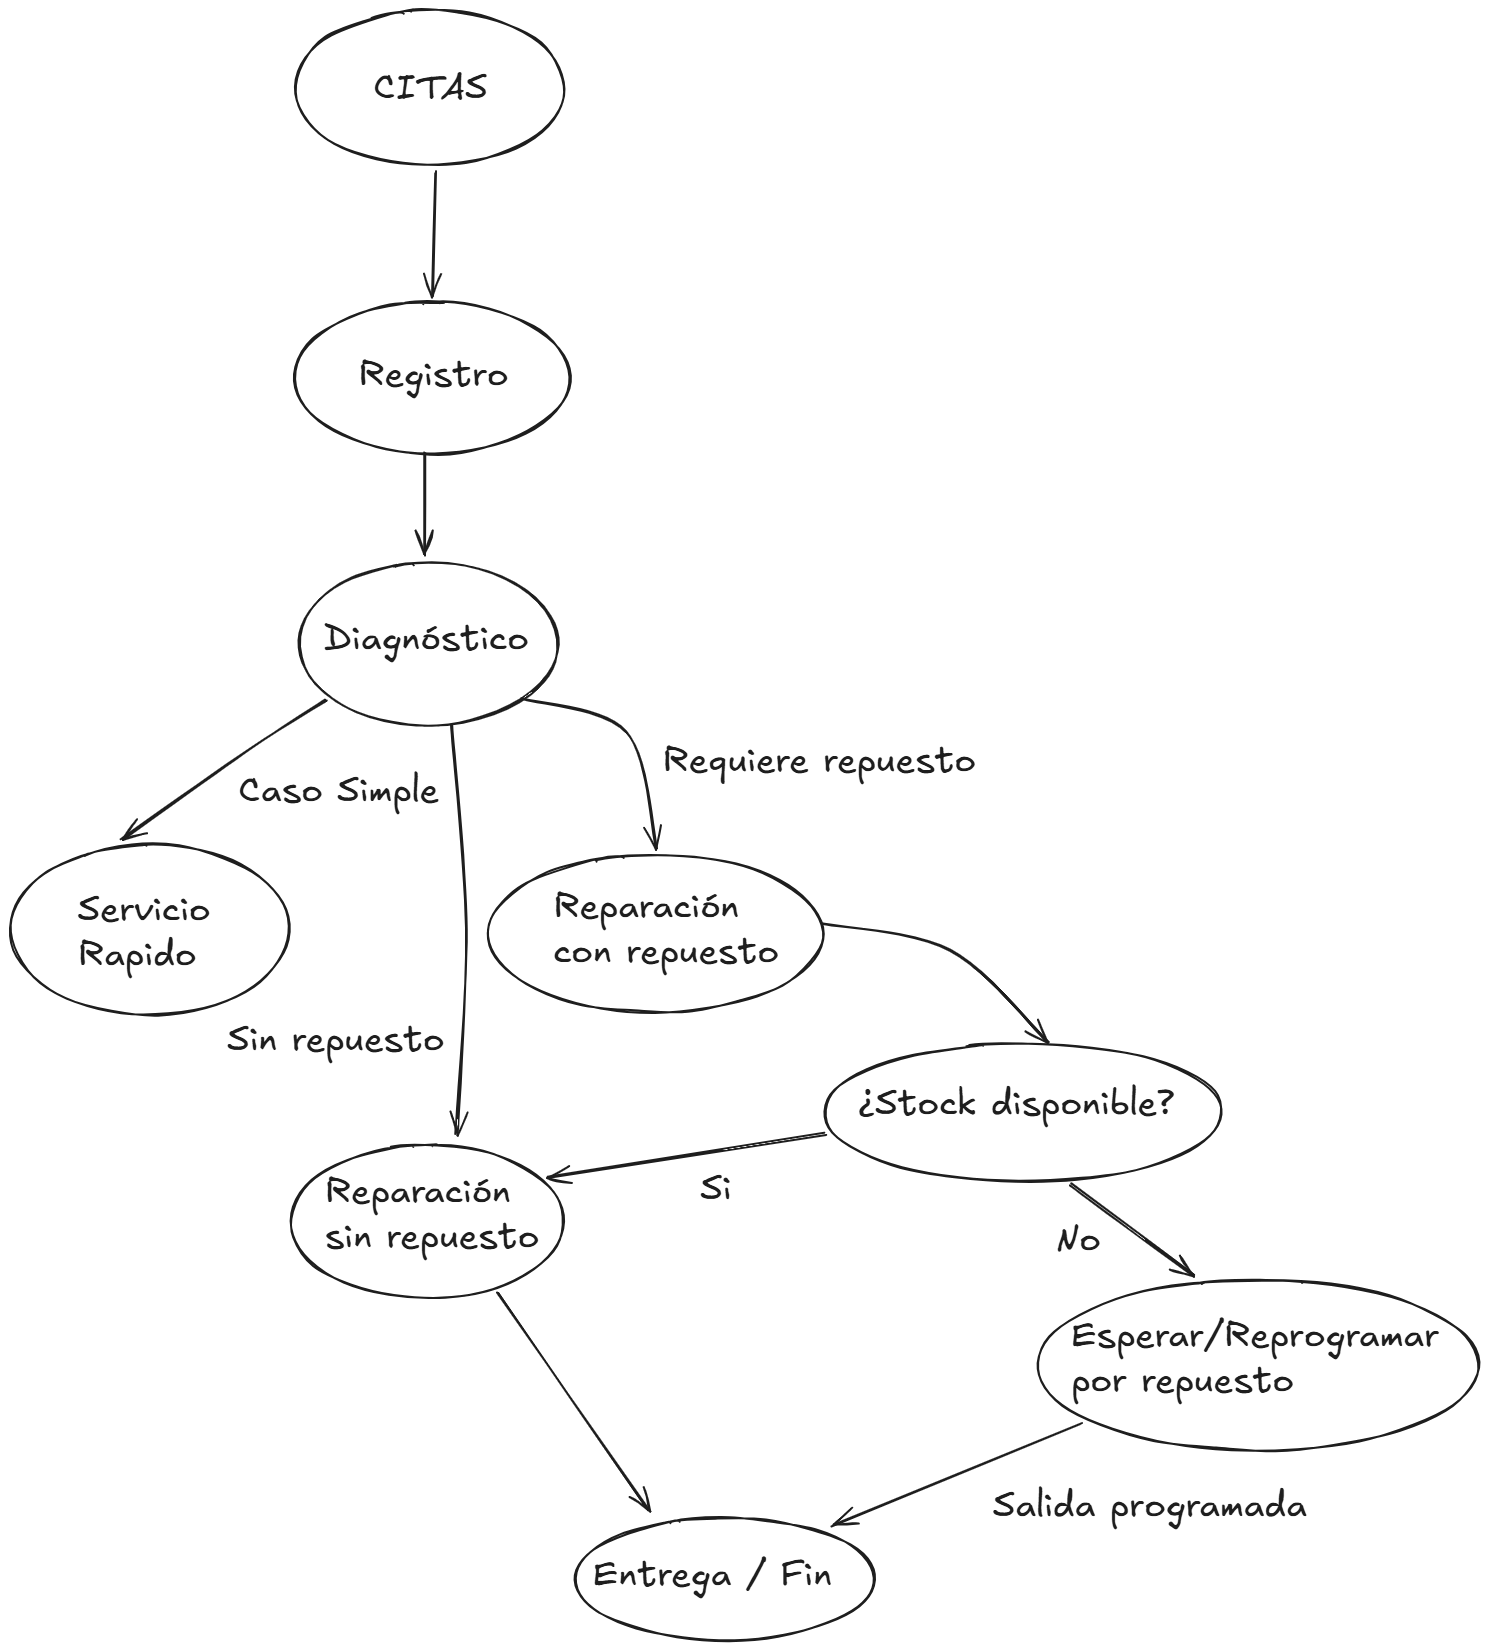

**b) Identificación de entidades, generadores y ramas.**

- **Entidades:** incidente smartphone (cliente + dispositivo).

    - Atributos: tipo entrada (walk-in/cita), modelo, gravedad, repuesto requerido, prioridad.

- **Generadores:**

    - **Citas:** programadas (determinista).

- Ramas (decisión post-diagnóstico):

    - Servicio rápido → Fin.

    - Reparación sin repuesto → Reparación → Fin.

    - Reparación con repuesto → Si stock → Reparación → Fin; Si no → Espera/reprogramación/derivación.

**c) Recursos necesarios por actividad (tipo y cantidad), e indica si alguno es compartido.**

- **Recepción / Registro:** 1 administrativo (dedicado).

- **Diagnóstico:** Técnicos de diagnóstico (2 técnicos; 1–2 estaciones diagnósticas). Estación diagnóstica puede ser compartida.

- **Reparación básica:** Técnicos de reparación (3 técnicos) + bancos de trabajo (2–3 bancos), bancos compartidos entre técnicos si n_tecnicos > n_bancos.

- **Reparación con repuesto:** Técnico + unidad de repuesto (stock limitado) + banco. Repuesto es recurso consumible compartido (inventario).

- **Reemplazo de pantalla (especializado):** Técnico especializado (1) + estación limpia (compartida si disponible).

- **Control de calidad / Entrega:** 1 persona (puede alternar con recepción → recurso compartido).

*Parámetro a variar en escenarios: n_tecnicos, n_bancos, niveles de stock.*

**d) Hipótesis de distribuciones para tiempos entre llegadas y tiempos de actividad (y de dónde obtendrías datos).**

**Tiempos entre llegadas**

- **Citas:** Determinista (agenda).

**Tiempos de actividad**

- **Diagnóstico:** Lognormal(μ,σ).

- **Reparación sin repuesto:** Gamma(k,θ).

- **Reparación con repuesto:** Lognormal + posible espera por reposición.

- **Reemplazo de pantalla:** Normal truncada (menor variabilidad).

**Fuentes de datos para estimación**

- Historial operativo del taller (timestamps inicio/fin).

- Registros de inventario y lead times proveedores.

- Observación directa / muestreo y encuestas a técnicos.

- Ajuste empírico (MLE) si hay suficientes datos, o benchmarks de industria si no.

**e) Que salidas clave reportarías.**

1. Tiempo medio de espera por cola (recepción, diagnóstico, espera por repuesto, reparación).

2. Lead time total por entidad (llegada → entrega): media y percentiles (50/90/95).

3. Throughput diario por tipo de servicio.

4. Utilización de recursos (% ocupación de técnicos, bancos, administrativos).

5. Probabilidad/porcentaje de falta de stock (casos que esperan por repuesto).

6. Tamaño medio de cola (nivel de backlog) y distribución horaria.

7. Impacto de escenarios “what-if” (p. ej. +1 técnico, +1 banco, aumentar stock) sobre métricas 1–4 (delta y percentiles).

## Pregunta 3 (25 pts) — Variabilidad, replicación y resumen de resultados

a) Define **ejecución** (corrida) y **ensayo**. Explica por qué en DES estocástica se requieren múltiples ejecuciones. (15 pts)

b) ¿Qué **estadísticas** reportarías y por qué? (10 pts)


### Espacio para tu respuesta (P3)

**a) Ejecución (corrida) y ensayo – explicación**

- **Ejecución (corrida):**
Una simulación completa del modelo con una única semilla de aleatoriedad. Produce un conjunto específico de resultados para esa realización del sistema.

- **Ensayo (replicación):**
Conjunto de múltiples corridas independientes del mismo modelo para capturar la variabilidad inherente del sistema estocástico.

- **¿Por qué se requieren múltiples corridas en DES estocástica?**
Debido a que los tiempos (llegadas, servicios, fallas) son aleatorios, una sola corrida no es representativa del comportamiento real. Varias corridas permiten:

  - Minimizar el efecto del azar, Obtener medidas promedio confiables, Calcular medidas de variabilidad, Comparar escenarios con rigor estadístico.

**b) ¿Qué **estadísticas** reportarías y por qué?**

| Estadística | Qué mide | ¿Por qué? |
|-------------|----------|-------------------------|
| Media (promedios) | Desempeño del sistema (tiempos de espera, en sistema) | Permite comparar escenarios y medir eficiencia |
| Utilización de recursos | % de ocupación de servidores/equipos | Identifica cuellos de botella |
| Throughput | Entidades atendidas por unidad de tiempo | Evalúa capacidad del sistema |
| Percentiles (p90, p95) | Comportamiento en casos altos de espera | Evalúa calidad del servicio |
| Desviación estándar | Variabilidad del sistema | Muestra estabilidad o congestión |
| Intervalos de confianza | Precisión de estimación de resultados | Soporta decisiones sin depender del azar |



## Pregunta 4 (25 pts) — Paradigma conceptual en SimPy

a) ¿Qué es una **función generadora** en Python y por qué SimPy la usa como generadores de llegadas y trayectorias de entidades? (8 pts)

b) ¿Cómo maneja SimPy el **tiempo de simulación** y el **agendamiento de eventos**? (7 pts)

c) Para un paso de tu modelo de la Pregunta 2, describe conceptualmente cómo representarías: la **cola** (y su política), la **solicitud de un recurso**, el **tiempo de servicio** y la **liberación** del recurso. (10 pts)


### Espacio para tu respuesta (P4)

**a) ¿Qué es una función generadora en Python y por qué SimPy la usa?**

- Una función generadora en Python es una función que produce una secuencia de valores usando la palabra clave yield, en lugar de retornar un valor único. Cada vez que se ejecuta un yield, la función pausa su ejecución y se reanuda más tarde desde el mismo punto.

- SimPy las usa porque las entidades (procesos) en simulación progresan en el tiempo y deben esperar eventos (como colas, recursos, demoras). Gracias a yield, un proceso puede "pausar" su ejecución y reanudarse cuando el evento ocurre, permitiendo modelar comportamientos como llegadas y trayectorias paso a paso en el tiempo sin bloquear la simulación.

**b) ¿Cómo maneja SimPy el tiempo de simulación y el agendamiento de eventos?**

- SimPy utiliza un reloj de simulación que avanza de forma discreta de evento en evento. Internamente maneja una lista de eventos programados (agenda de eventos) ordenada por tiempo. Cuando se ejecuta la simulación:

- Toma el evento más próximo en el tiempo.

- Actualiza el reloj de simulación a ese instante.

- Ejecuta el evento (por ejemplo, inicio de servicio, fin de llegada, liberación).

- Puede generar nuevos eventos futuros que se agregan a la agenda.

- El tiempo no avanza de forma continua, sino que salta entre eventos relevantes.

**c) Representación conceptual en SimPy para un paso de tu modelo**

- Para el proceso "Diagnóstico técnico" del modelo de reparación de teléfonos:

| Concepto en DES | Representación conceptual en SimPy |
|------------------|------------------------------------|
| Cola + política | La cola se gestiona automáticamente al solicitar un recurso (`Resource`), política por defecto: **FIFO** |
| Solicitud de recurso | `with tecnico_diag.request() as req: yield req` (si no hay recurso disponible, la entidad espera en cola) |
| Tiempo de servicio | `yield env.timeout(tiempo_diagnostico)` usando una distribución como `random.expovariate()` |
| Liberación de recurso | Automática al salir del bloque `with`: el recurso queda disponible para el siguiente en cola |

Este enfoque permite modelar la dinámica: esperar turno → obtener técnico → diagnóstico → liberar recurso para el siguiente cliente.